# 🤖 CSV Supervisor Multi-Agent 시스템

Supervisor 패턴으로 CSV Filter Agent와 Visualization Agent를 조정합니다.

## 아키텍처
```
사용자 질문 → Supervisor → Filter Agent (데이터 필터링)
                       → Viz Agent (그래프 생성)
```


## 1. 환경 설정


In [1]:
import os
import sys
from pathlib import Path

# 현재 디렉토리를 모듈 경로에 추가
sys.path.insert(0, str(Path.cwd()))

from dotenv import load_dotenv

load_dotenv(override=True)

print("✅ 환경 설정 완료!")

# (선택) Langfuse 계측 준비
# - LANGFUSE_PUBLIC_KEY / LANGFUSE_SECRET_KEY / LANGFUSE_HOST 가 설정돼 있으면
#   invoke 시 Langfuse에 Trace/Span/Generation이 자동 수집됩니다.
from langfuse_instrumentation import get_langfuse_handler, invoke_with_langfuse

_ = get_langfuse_handler()  # 있으면 enabled 메시지 출력, 없으면 None

✅ 환경 설정 완료!
✅ Langfuse enabled: host=http://localhost:3001, session_id=csv-supervisor-20260114-000239


## 2. 도구 정의


In [2]:
from langchain_core.tools import tool
from tools import load_and_filter_csv, create_chart, get_related_info


@tool
def filter_csv(oper: str = None, para: str = None) -> str:
    """CSV 파일에서 oper, para 조건으로 데이터를 필터링합니다.

    Args:
        oper: 필터링할 oper 값 (예: OP001, OP002)
        para: 필터링할 para 값 (예: TEMP, PRESSURE, HUMIDITY)
    """
    return load_and_filter_csv(oper=oper, para=para)


@tool
def generate_chart(oper: str, para: str, chart_type: str = "line") -> str:
    """시계열 데이터를 차트로 시각화합니다.

    Args:
        oper: 조회할 oper 값 (예: OP001)
        para: 조회할 para 값 (예: TEMP, PRESSURE)
        chart_type: 차트 유형 (line 또는 bar)
    """
    return create_chart(oper=oper, para=para, chart_type=chart_type)


@tool
def get_relation(oper: str) -> str:
    """특정 oper의 연관 oper와 para 목록을 조회합니다.

    Args:
        oper: 조회할 oper 값 (예: OP001)
    """
    return get_related_info(oper=oper)


print("✅ 도구 정의 완료!")

✅ 도구 정의 완료!


## 3. Agent 생성


In [3]:
from langgraph.prebuilt import create_react_agent
from openrouter_llm import get_llm

llm = get_llm()

# CSV Filter Agent
filter_agent = create_react_agent(
    model=llm,
    tools=[filter_csv],
    prompt=(
        "당신은 CSV 데이터 필터링 전문 에이전트입니다.\n\n"
        "역할:\n"
        "- filter_data.csv 파일에서 사용자가 요청한 조건으로 데이터를 필터링합니다.\n"
        "- oper(운영코드)와 para(파라미터) 기준으로 필터링할 수 있습니다.\n\n"
        "사용 가능한 값:\n"
        "- oper: OP001, OP002, OP003, OP004, OP005, OP006, OP007\n"
        "- para: TEMP, PRESSURE, HUMIDITY, FLOW, VOLTAGE, CURRENT, VIBRATION, SPEED\n\n"
        "규칙:\n"
        "- 필터링 작업만 수행하세요.\n"
        "- 결과를 명확하게 보고하세요."
    ),
    name="filter_agent",
)

# Relation Agent
relation_agent = create_react_agent(
    model=llm,
    tools=[get_relation],
    prompt=(
        "당신은 oper 연관 정보 조회 전문 에이전트입니다.\n\n"
        "역할:\n"
        "- relation_data.csv 파일에서 특정 oper의 연관 oper와 para 목록을 조회합니다.\n"
        "- 사용자가 특정 oper의 '연관', '관련' 정보를 요청할 때 응답합니다.\n\n"
        "사용 가능한 oper:\n"
        "- OP001, OP002, OP003, OP004, OP005, OP006, OP007\n\n"
        "규칙:\n"
        "- 연관 정보 조회 작업만 수행하세요.\n"
        "- 결과를 명확하게 보고하세요.\n"
        "- 사용자가 연관 파라의 trend/그래프를 요청하면, 연관 정보만 조회하고 보고하세요."
    ),
    name="relation_agent",
)

# Visualization Agent
viz_agent = create_react_agent(
    model=llm,
    tools=[generate_chart],
    prompt=(
        "당신은 데이터 시각화 전문 에이전트입니다.\n\n"
        "역할:\n"
        "- timeseries_data.csv 파일의 시계열 데이터를 차트로 시각화합니다.\n"
        "- oper와 para를 지정하여 해당 데이터의 시계열 그래프를 생성합니다.\n\n"
        "사용 가능한 데이터:\n"
        "- OP001: TEMP, PRESSURE\n"
        "- OP002: TEMP, HUMIDITY\n"
        "- OP003: FLOW\n\n"
        "차트 유형:\n"
        "- line: 선 그래프 (기본)\n"
        "- bar: 막대 그래프\n\n"
        "규칙:\n"
        "- 시각화 작업만 수행하세요.\n"
        "- 생성된 차트 파일 경로를 보고하세요."
    ),
    name="viz_agent",
)

print("✅ Filter Agent, Relation Agent, Visualization Agent 생성 완료!")

ImportError: cannot import name '_DirectlyInjectedToolArg' from 'langchain_core.tools.base' (/Users/daehwankim/Documents/langgraph-tutorial-main/.venv/lib/python3.13/site-packages/langchain_core/tools/base.py)

## 4. Supervisor 생성


In [10]:
from langgraph_supervisor import create_supervisor

# Supervisor 생성 - langgraph-supervisor 라이브러리 사용
supervisor = create_supervisor(
    model=llm,
    agents=[filter_agent, relation_agent, viz_agent],
    prompt=(
        "당신은 CSV 데이터 분석 작업을 조정하는 Supervisor입니다.\n\n"
        "관리하는 에이전트:\n"
        "1. filter_agent: oper/para 목록 조회 (filter_data.csv 사용)\n"
        "2. relation_agent: 특정 oper의 연관 oper/para 정보 조회 (relation_data.csv 사용)\n"
        "3. viz_agent: 시계열 데이터 차트/그래프 생성 (timeseries_data.csv 사용)\n\n"
        "**중요: 작업 분배 규칙**\n"
        "- '연관', '관련', 'related' 키워드가 포함되면 → relation_agent에게 위임\n"
        "- 다음 키워드가 포함되면 → viz_agent에게 위임: 그래프, 차트, 시각화, 그려, plot, 시계열, trend\n"
        "- 데이터 목록/필터링만 요청할 때 → filter_agent에게 위임\n\n"
        "**멀티 에이전트 협업 규칙**\n"
        "- '연관 파라의 trend/그래프' 요청 시:\n"
        "  1. 먼저 relation_agent에게 연관 정보를 조회 요청\n"
        "  2. 조회된 연관 para 목록을 기반으로 viz_agent에게 각 para의 차트 생성 요청\n"
        "  3. 모든 차트가 생성되면 결과를 종합하여 보고\n\n"
        "예시:\n"
        "- 'OP001의 연관 파라 알려줘' → relation_agent (연관 키워드)\n"
        "- 'OP001의 TEMP 값을 그래프로 그려줘' → viz_agent (그래프 키워드)\n"
        "- 'OP001의 연관 파라 trend 그려줘' → relation_agent 조회 후 → viz_agent 협업\n"
        "- 'OP001 데이터 목록 보여줘' → filter_agent (목록 키워드)\n\n"
        "주의사항:\n"
        "- 직접 작업하지 말고 반드시 에이전트에게 위임하세요.\n"
        "- 한국어로 응답하세요."
    ),
    add_handoff_back_messages=True,
    output_mode="full_history",
).compile()

print("✅ Supervisor 생성 완료!")

✅ Supervisor 생성 완료!


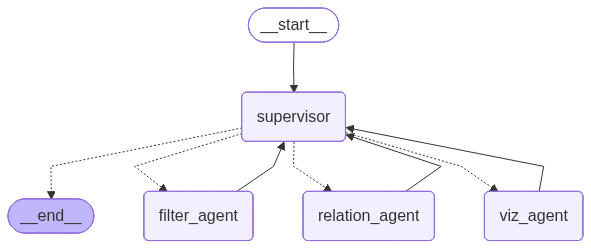

In [11]:
# 그래프 시각화
from IPython.display import display, Image

try:
    display(Image(supervisor.get_graph().draw_mermaid_png()))
except Exception as e:
    # ASCII로 시각화
    print("📊 Supervisor 그래프 구조:\n")
    print(supervisor.get_graph().draw_ascii())

## 5. 테스트 실행

### 5.1 Filter Agent 테스트


In [ ]:
query = "oper가 OP001인 데이터를 보여줘"
print(f"📝 질문: {query}\n")

result = supervisor.invoke({"messages": [{"role": "user", "content": query}]})
print(f"📊 결과:\n{result['messages'][-1].content}")

📝 질문: oper가 OP001인 데이터를 보여줘

⚠️ Langfuse 패키지를 import 할 수 없습니다: Please install langchain to use the Langfuse langchain integration: 'pip install langchain'
   해결: `uv add langfuse` 후 `uv sync` 또는 `pip install langfuse`
📊 결과:
oper가 OP001인 데이터는 다음과 같습니다:

| oper  | para     |
|-------|----------|
| OP001 | TEMP     |
| OP001 | PRESSURE |
| OP001 | HUMIDITY |
| OP001 | FLOW     |


### 5.2 Visualization Agent 테스트


In [ ]:
query = "OP001의 TEMP 값을 시계열 그래프로 그려줘"
print(f"📝 질문: {query}\n")

result = invoke_with_langfuse(supervisor, query, tags=["viz"])
print(f"📊 결과:\n{result['messages'][-1].content}")

📝 질문: OP001의 TEMP 값을 시계열 그래프로 그려줘

📊 결과:
OP001의 TEMP 값을 시계열 그래프로 시각화한 결과입니다. 생성된 차트 파일은 다음 경로에서 확인하실 수 있습니다:

/Users/daehwankim/Documents/langgraph-tutorial-main/supervisor/output/OP001_TEMP_line.png


### 5.3 생성된 차트 확인


📈 OP001_PRESSURE_line.png


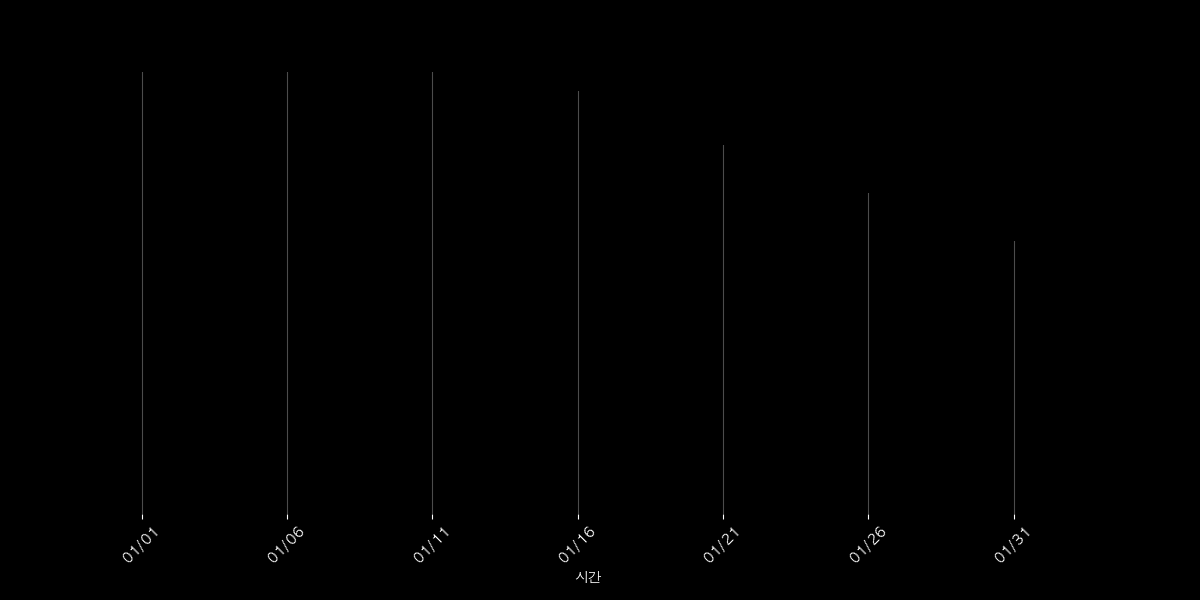

📈 OP001_TEMP_line.png


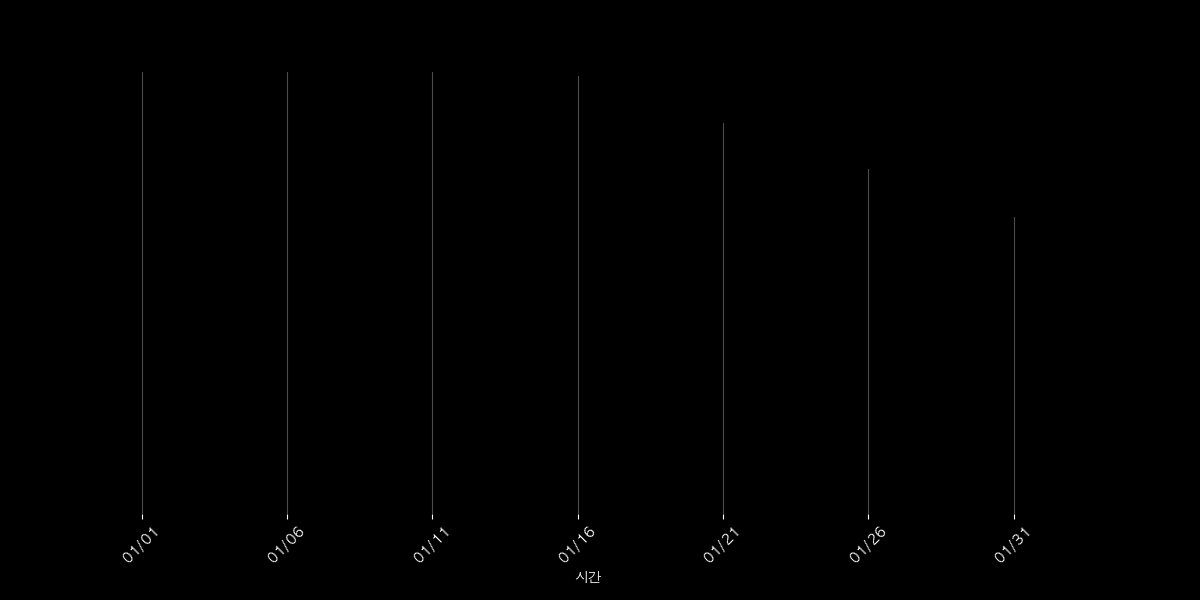

📈 OP003_FLOW_line.png


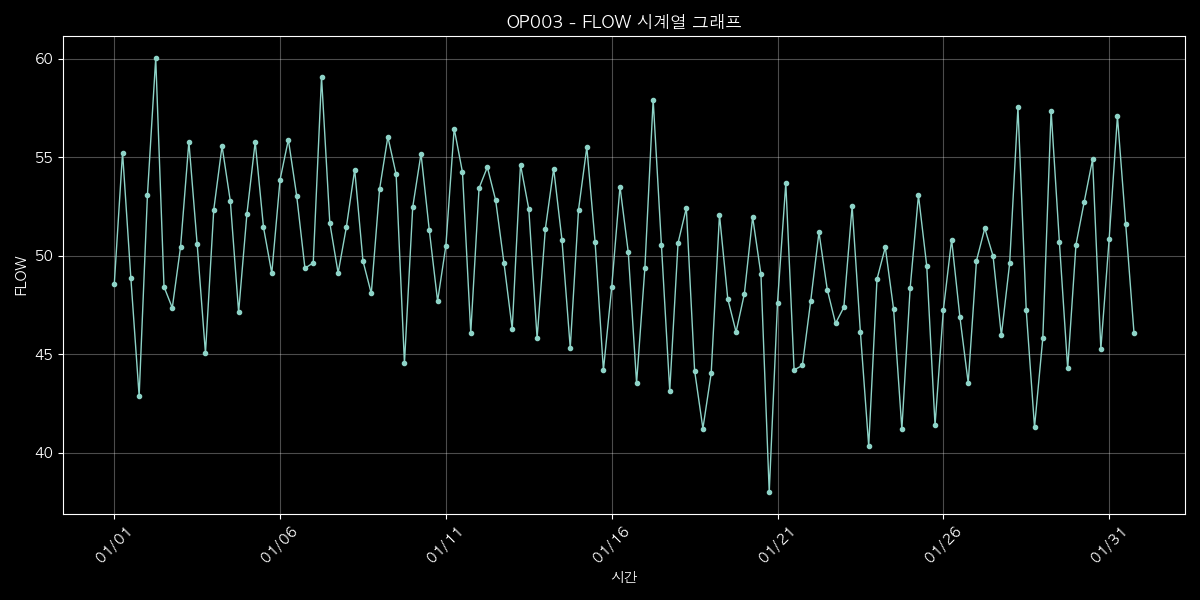

In [12]:
from IPython.display import Image, display
from pathlib import Path

output_dir = Path("output")
if output_dir.exists():
    for img_file in output_dir.glob("*.png"):
        print(f"📈 {img_file.name}")
        display(Image(filename=str(img_file)))
else:
    print("아직 생성된 차트가 없습니다.")

## 6. 자유 질의


In [ ]:
# 원하는 질문을 입력하세요
query = "OP003의 FLOW 데이터를 선 그래프로 보여줘"

print(f"📝 질문: {query}\n")
result = invoke_with_langfuse(supervisor, query, tags=["viz"])
print(f"📊 결과:\n{result['messages'][-1].content}")

📝 질문: OP003의 FLOW 데이터를 선 그래프로 보여줘

📊 결과:
OP003의 FLOW 데이터에 대한 선 그래프가 생성되었습니다. 차트 파일은 다음 경로에서 확인하실 수 있습니다:

`/Users/daehwankim/Documents/langgraph-tutorial-main/supervisor/output/OP003_FLOW_line.png`


In [ ]:
# 원하는 질문을 입력하세요
query = "OP001의 연관 파라 알려줘"

print(f"📝 질문: {query}\n")
result = invoke_with_langfuse(supervisor, query, tags=["relation"])
print(f"📊 결과:\n{result['messages'][-1].content}")

📝 질문: OP001의 연관 파라 알려줘

📊 결과:
OP001의 연관 정보는 다음과 같습니다:

🔗 **연관 Oper**: OP002, OP003  
📊 **연관 Para**: TEMP, PRESSURE  

더 필요한 정보가 있으시면 말씀해 주세요!


📝 질문: OP001의 연관 파라 trend 그려줘

📊 결과:
OP001의 연관 파라 TEMP와 PRESSURE에 대한 시계열 그래프가 생성되었습니다.

- TEMP 차트: [OP001_TEMP_line.png](file:///Users/daehwankim/Documents/langgraph-tutorial-main/supervisor/output/OP001_TEMP_line.png)
- PRESSURE 차트: [OP001_PRESSURE_line.png](file:///Users/daehwankim/Documents/langgraph-tutorial-main/supervisor/output/OP001_PRESSURE_line.png)

추가적으로 필요한 작업이 있으면 말씀해 주세요!
📈 OP001_PRESSURE_line.png


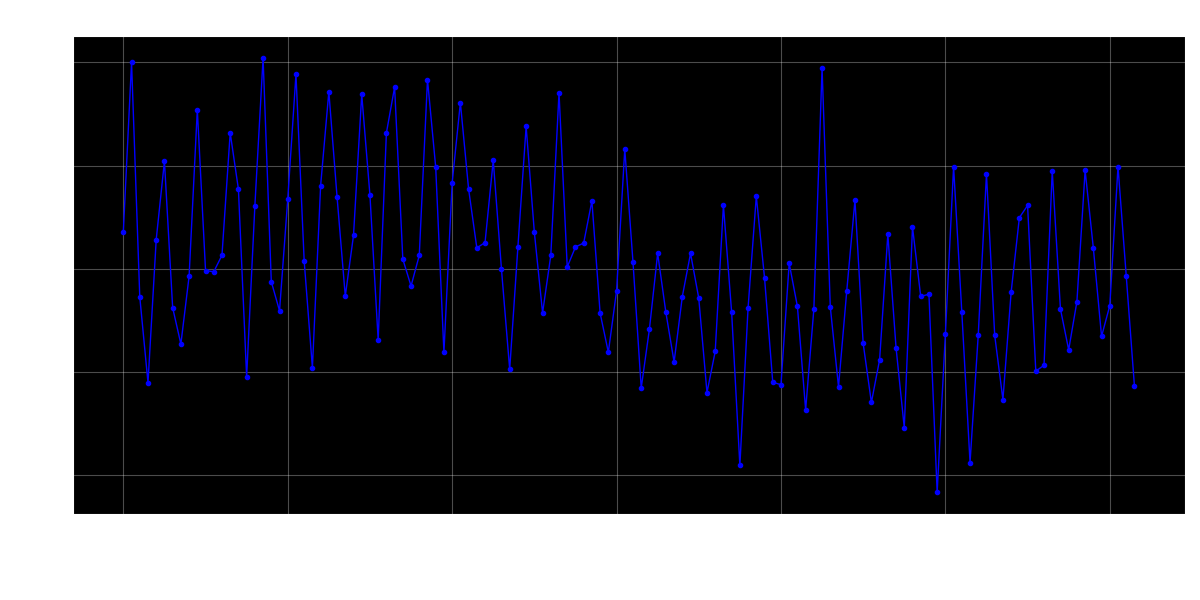

📈 OP001_TEMP_line.png


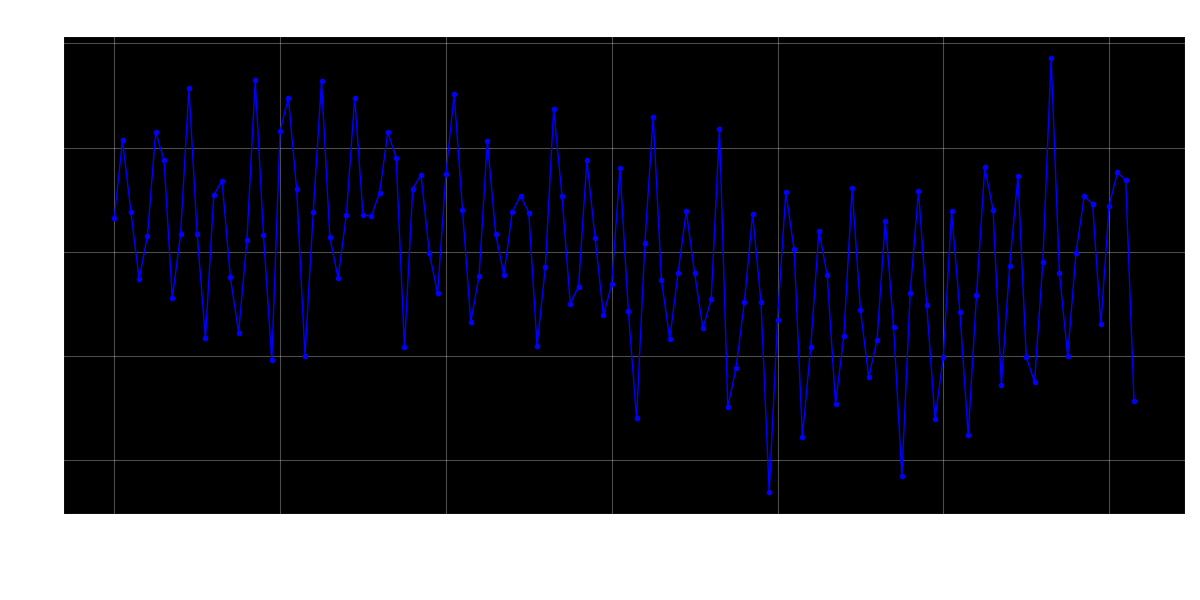

📈 OP003_FLOW_line.png


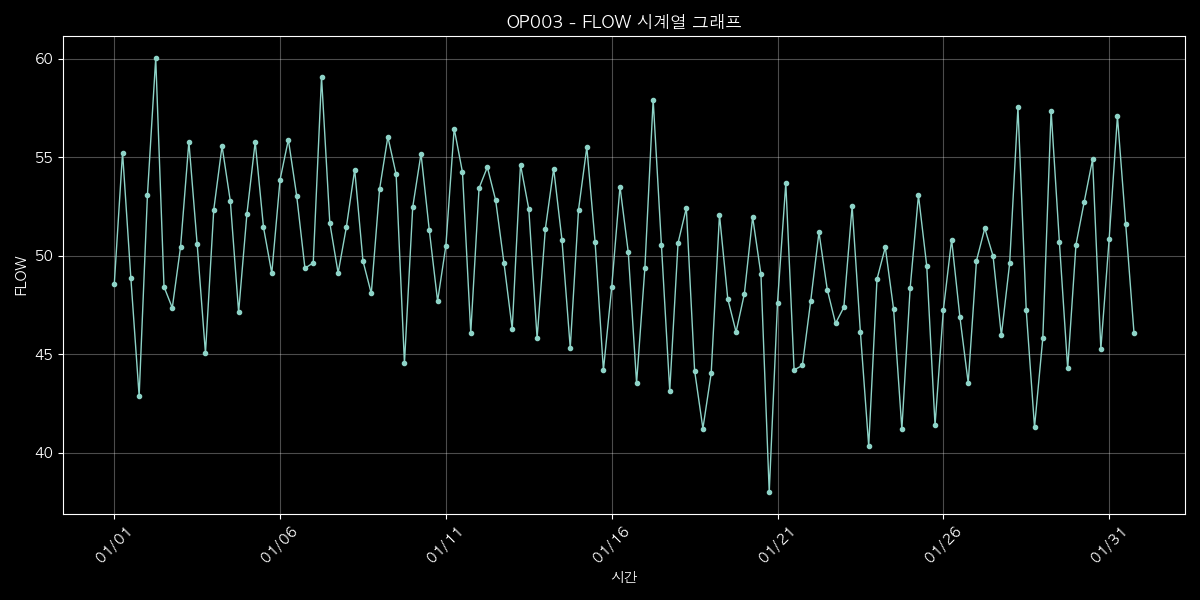

In [ ]:
# 원하는 질문을 입력하세요
query = "OP001의 연관 파라 trend 그려줘"

print(f"📝 질문: {query}\n")
result = invoke_with_langfuse(
    supervisor, query, tags=["relation", "viz", "multi_agent"]
)
print(f"📊 결과:\n{result['messages'][-1].content}")
output_dir = Path("output")
if output_dir.exists():
    for img_file in output_dir.glob("*.png"):
        print(f"📈 {img_file.name}")
        display(Image(filename=str(img_file)))
else:
    print("아직 생성된 차트가 없습니다.")